In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
train_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
val_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
test_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test"

In [ ]:
for folder in os.listdir(val_path):
    print(folder, len(os.listdir(os.path.join(train_path, folder))))

In [ ]:
class_names = os.listdir(train_path)

print(class_names)
len(class_names)

In [ ]:
IMG_SIZE = (224,224)

BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

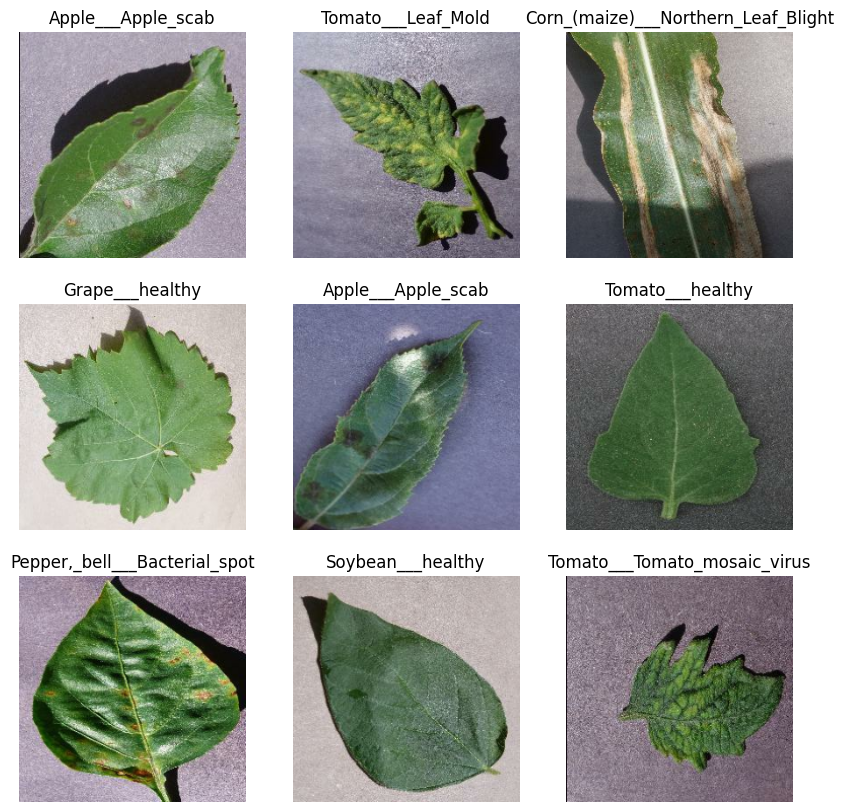

In [17]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(train_ds.class_names[labels[i]])

        plt.axis("off")

plt.show()

In [16]:
model = keras.Sequential([

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(38,activation='softmax')
])

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 52, 52, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 26, 26, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 256)               │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 38)                │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,254,438 (84.89 MB)

 Trainable params: 22,254,438 (84.89 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [17]:
checkpoint = ModelCheckpoint(
    "best_cotton_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [18]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [19]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/20
4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3394 - loss: 2.3801
Epoch 1: val_accuracy improved from None to 0.78318, saving model to best_cotton_model.keras

Epoch 1: finished saving model to best_cotton_model.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 193s 41ms/step - accuracy: 0.5239 - loss: 1.6344 - val_accuracy: 0.7832 - val_loss: 0.6977 - learning_rate: 0.0010
Epoch 2/20
4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7489 - loss: 0.8096
Epoch 2: val_accuracy improved from 0.78318 to 0.87742, saving model to best_cotton_model.keras

Epoch 2: finished saving model to best_cotton_model.keras
4394/4394 ━━━━━━━━━━━━━━━━━━━━ 190s 41ms/step - accuracy: 0.7672 - loss: 0.7428 - val_accuracy: 0.8774 - val_loss: 0.4025 - learning_rate: 0.0010
Epoch 3/20
4393/4394 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8134 - loss: 0.6095
Epoch 3: val_accuracy improved from 0.87742 to 0.88601, saving model to best_cotton_model.keras

Epoch 3: finished saving model to bes

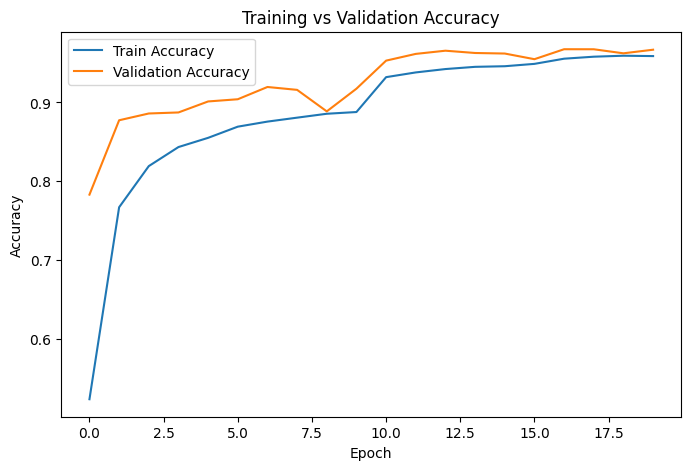

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

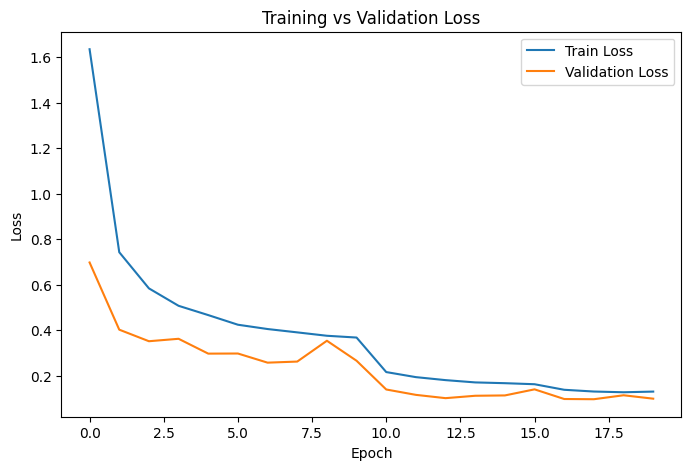

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [18]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np


for file in os.listdir(test_path):

    path = os.path.join(test_path, file)

    img = image.load_img(path, target_size=(224,224))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)

    label = class_names[np.argmax(pred)]

    confidence = np.max(pred)

    print(file)
    print("Prediction :", label)
    print("Confidence :", confidence)
    print("-"*50)

TomatoEarlyBlight6.JPG
Prediction : Tomato___Tomato_mosaic_virus
Confidence : 0.99909294
--------------------------------------------------
TomatoYellowCurlVirus4.JPG
Prediction : Tomato___Tomato_mosaic_virus
Confidence : 0.99995637
--------------------------------------------------
TomatoYellowCurlVirus6.JPG
Prediction : Tomato___Tomato_mosaic_virus
Confidence : 0.86433935
--------------------------------------------------
PotatoHealthy2.JPG
Prediction : Peach___Bacterial_spot
Confidence : 0.7427054
--------------------------------------------------
TomatoYellowCurlVirus5.JPG
Prediction : Tomato___Tomato_mosaic_virus
Confidence : 0.9980282
--------------------------------------------------
PotatoEarlyBlight2.JPG
Prediction : Peach___Bacterial_spot
Confidence : 0.9882983
--------------------------------------------------
TomatoYellowCurlVirus3.JPG
Prediction : Tomato___Tomato_mosaic_virus
Confidence : 0.9984426
--------------------------------------------------
TomatoEarlyBlight3.JPG
P

In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=16,
    shuffle=True
)

CLASS_NAMES = train_ds.class_names

NUM_CLASSES = len(CLASS_NAMES)

Found 70295 files belonging to 38 classes.


In [18]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

In [19]:
base_model.trainable = False

In [20]:
inputs = keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

In [21]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_efficientnet.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2
)